In [4]:
"""
AQI Project - Exploratory Data Analysis (EDA)
Complete analysis with proper color coding
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# AQI Color Mapping (as per requirements)
AQI_COLORS = {
    'Good': '#10b981',
    'Moderate': '#f59e0b',
    'Unhealthy for Sensitive': '#f97316',
    'Unhealthy': '#ef4444',
    'Very Unhealthy': '#8b5cf6',
    'Hazardous': '#1f2937'
}

# AQI Ranges
AQI_RANGES = [
    (0, 50, 'Good', '#10b981'),
    (51, 100, 'Moderate', '#f59e0b'),
    (101, 150, 'Unhealthy for Sensitive', '#f97316'),
    (151, 200, 'Unhealthy', '#ef4444'),
    (201, 300, 'Very Unhealthy', '#8b5cf6'),
    (301, 500, 'Hazardous', '#1f2937')
]

print("AQI PROJECT - EXPLORATORY DATA ANALYSIS")
print("="*60)
print("Libraries imported successfully!")

AQI PROJECT - EXPLORATORY DATA ANALYSIS
Libraries imported successfully!


In [6]:
# Load the data
df = pd.read_csv("../data/processed_aqi_data.csv")

print("DATA LOADING AND INSPECTION")
print("="*60)

print(f"\nDataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\nFirst 5 rows:")
df.head()

DATA LOADING AND INSPECTION

Dataset Shape: (230, 36)
Rows: 230, Columns: 36

First 5 rows:


,datetime,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3,...,aqi_rolling_mean_12,aqi_rolling_std_6,aqi_change,aqi_pct_change,pm25_pm10_ratio,no2_so2_ratio,co_no2_ratio,o3_no2_ratio,aqi_class,aqi_category
0,2026-05-12 17:37:34.401042,57,124.189000,0.01,0.098000,67.52,0.38,35.1900,119.966000,0,...,197.083333,118.119854,-308.0,-84.383562,0.290908,0.071014,113.104736,61.493625,2,Moderate
1,2026-05-12 17:37:39.607750,225,232.481808,0.01,0.214032,67.52,0.38,96.0687,262.005744,0,...,195.916667,111.899955,168.0,294.736842,0.365272,0.155096,191.495618,55.616326,5,Very Unhealthy
2,2026-05-12 17:37:44.840621,89,124.189000,0.01,0.098000,67.52,0.38,35.1900,119.966000,0,...,192.750000,112.242000,-136.0,-60.444444,0.290908,0.071014,113.104736,61.493625,2,Moderate
3,2026-05-12 17:37:50.015519,258,232.481808,0.01,0.214032,67.52,0.38,96.0687,262.005744,0,...,200.083333,115.002029,169.0,189.887640,0.365272,0.155096,191.495618,55.616326,5,Very Unhealthy
4,2026-05-12 17:37:55.230588,132,161.445700,0.01,0.137200,67.52,0.38,52.7850,167.952400,0,...,205.583333,116.357495,-126.0,-48.837209,0.312425,0.099420,141.967728,59.373901,3,Unhealthy for Sensitive


In [7]:
print("DATA INFORMATION")
print("="*60)

print("\nColumn names and data types:")
print(df.dtypes)

print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)

print("\nNumerical columns statistics:")
df.describe()

DATA INFORMATION

Column names and data types:
datetime                object
aqi                      int64
co                     float64
no                     float64
no2                    float64
o3                     float64
so2                    float64
pm2_5                  float64
pm10                   float64
nh3                      int64
hour                     int64
day                      int64
month                    int64
day_of_week              int64
weekend                float64
hour_sin               float64
hour_cos               float64
dow_sin                float64
dow_cos                float64
aqi_lag_1              float64
aqi_lag_3              float64
aqi_lag_6              float64
aqi_lag_12             float64
aqi_lag_24             float64
aqi_rolling_mean_3     float64
aqi_rolling_mean_6     float64
aqi_rolling_mean_12    float64
aqi_rolling_std_6      float64
aqi_change             float64
aqi_pct_change         float64
pm25_pm10_ratio        

,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3,hour,...,aqi_rolling_mean_6,aqi_rolling_mean_12,aqi_rolling_std_6,aqi_change,aqi_pct_change,pm25_pm10_ratio,no2_so2_ratio,co_no2_ratio,o3_no2_ratio,aqi_class
count,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.0,230.000000,...,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000
mean,182.100000,161.123524,0.004478,0.166602,46.153130,0.356957,44.532629,151.291959,0.0,18.008696,...,182.379710,182.471014,138.902323,-0.565217,1908.078232,0.262632,0.122588,135.910599,39.727795,3.665217
std,131.167693,58.972369,0.005323,0.073481,15.561211,0.045700,32.640498,78.492711,0.0,4.236452,...,21.960045,17.161047,28.359031,243.698508,4875.521822,0.064580,0.053356,43.535214,13.658709,1.767269
min,2.000000,74.820000,0.000000,0.040000,31.960000,0.150000,7.670000,43.620000,0.0,0.000000,...,126.333333,142.416667,75.976312,-478.000000,-99.583333,0.171896,0.031008,69.486239,24.679340,1.000000
25%,74.000000,97.461000,0.000000,0.098000,34.270000,0.330000,21.656250,85.690000,0.0,17.000000,...,167.750000,172.395833,118.154545,-209.750000,-72.759866,0.217985,0.071014,89.637458,28.228251,2.000000
50%,190.000000,171.576912,0.000000,0.152880,34.270000,0.370000,35.190000,133.372512,0.0,18.000000,...,184.916667,182.583333,138.027171,-20.500000,-8.457364,0.253536,0.120265,141.967728,31.370697,4.500000
75%,263.500000,218.498342,0.010000,0.214032,67.520000,0.380000,60.923362,216.450562,0.0,21.000000,...,197.250000,196.854167,163.028818,204.000000,294.036503,0.295375,0.160926,173.847602,55.616326,5.000000
max,497.000000,278.978170,0.020000,0.403603,67.520000,0.510000,124.889310,340.641101,0.0,23.000000,...,240.666667,218.166667,195.634779,484.000000,23000.000000,0.395963,0.278347,221.968210,63.102804,6.000000


In [13]:
print("MISSING VALUES CHECK:") # step 4

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing Values'] > 0]

if len(missing_df) > 0:
    print("\nColumns with missing values:")
    print(missing_df)
else:
    print("\nNo missing values found in the dataset!")

MISSING VALUES CHECK:

No missing values found in the dataset!


AQI CATEGORY DISTRIBUTION:

Category Distribution:
--------------------------------------------------------------------------------
  Very Unhealthy           :   80 samples
  Moderate                 :   48 samples
  Hazardous                :   35 samples
  Good                     :   33 samples
  Unhealthy for Sensitive  :   32 samples
  Unhealthy                :    2 samples


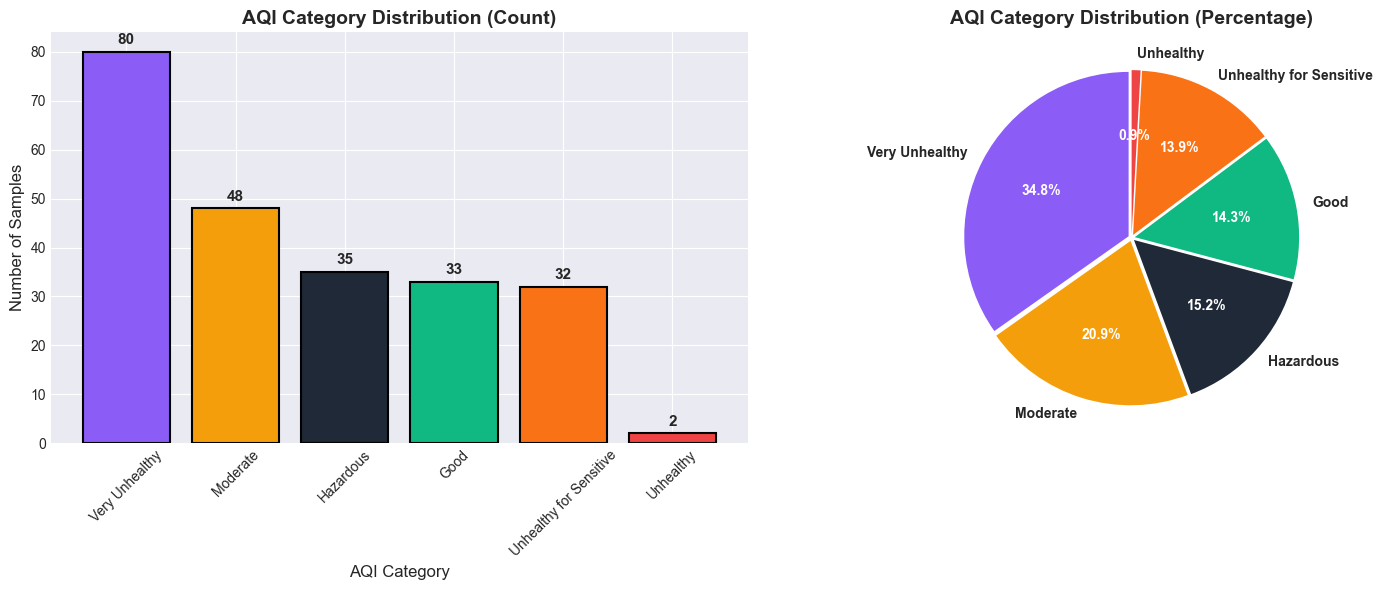

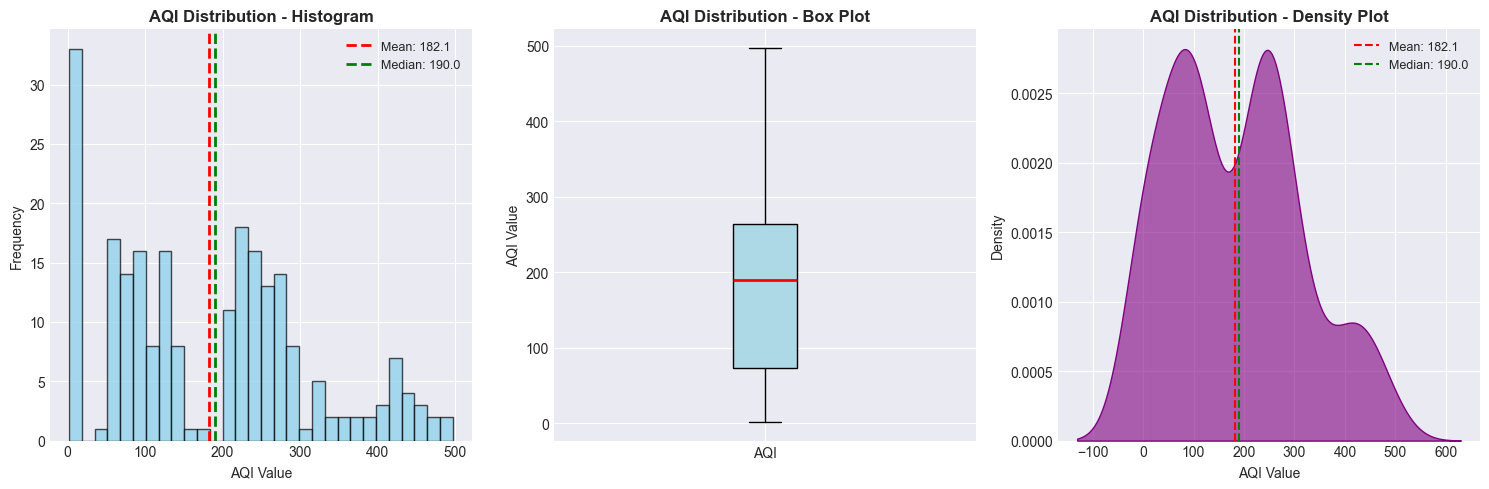

AQI STATISTICS SUMMARY:
--------------------------------------------------------------------------------
  Mean AQI: 182.10
  Median AQI: 190.00
  Standard Deviation: 131.17
  Minimum AQI: 2.00
  Maximum AQI: 497.00
  25th Percentile: 74.00
  75th Percentile: 263.50

 CATEGORY DISTRIBUTION DETAILS:
--------------------------------------------------------------------------------
  Good                               :  33 samples ( 14.3%) ███████
  Moderate                           :  48 samples ( 20.9%) ██████████
  Unhealthy for Sensitive            :  32 samples ( 13.9%) ██████
  Unhealthy                          :   2 samples (  0.9%) 
  Very Unhealthy                     :  80 samples ( 34.8%) █████████████████
  Hazardous                          :  35 samples ( 15.2%) ███████

 EDA - AQI DISTRIBUTION COMPLETED


In [43]:
print("AQI CATEGORY DISTRIBUTION:")

# Function to map AQI value to category
def get_aqi_category(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Moderate'
    elif aqi <= 150:
        return 'Unhealthy for Sensitive'
    elif aqi <= 200:
        return 'Unhealthy'
    elif aqi <= 300:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

# Added category column
df['aqi_category'] = df['aqi'].apply(get_aqi_category)

# Count distribution
category_counts = df['aqi_category'].value_counts()
print("\nCategory Distribution:")
print("-"*80)
for category, count in category_counts.items():
    color = AQI_COLORS.get(category, '#gray')
    print(f"  {category:25}: {count:4} samples")

# Created figure with two subplots (Bar chart + Pie chart)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))


# BAR CHART
colors = [AQI_COLORS[cat] for cat in category_counts.index]
bars = axes[0].bar(category_counts.index, category_counts.values, 
                    color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, count in zip(bars, category_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 str(int(count)), ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[0].set_title('AQI Category Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('AQI Category', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)


# PIE CHART and Get valid categories and counts
valid_categories = list(category_counts.index)
valid_counts = list(category_counts.values)
pie_colors = [AQI_COLORS[cat] for cat in valid_categories]

wedges, texts, autotexts = axes[1].pie(
    valid_counts, 
    labels=valid_categories, 
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=90,
    explode=[0.02] * len(valid_categories),
    textprops={'fontsize': 10, 'fontweight': 'bold'}
)

# Style the percentage text 
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

# Style the category labels
for text in texts:
    text.set_fontsize(10)
    text.set_fontweight('bold')

axes[1].set_title('AQI Category Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# AQI STATISTICS - HISTOGRAM, BOX PLOT, KDE
fig, axes2 = plt.subplots(1, 3, figsize=(15, 5))

# Histogram
axes2[0].hist(df['aqi'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes2[0].set_title('AQI Distribution - Histogram', fontsize=12, fontweight='bold')
axes2[0].set_xlabel('AQI Value', fontsize=10)
axes2[0].set_ylabel('Frequency', fontsize=10)
axes2[0].axvline(df['aqi'].mean(), color='red', linestyle='--', linewidth=2, 
                  label=f'Mean: {df["aqi"].mean():.1f}')
axes2[0].axvline(df['aqi'].median(), color='green', linestyle='--', linewidth=2, 
                  label=f'Median: {df["aqi"].median():.1f}')
axes2[0].legend(fontsize=9)

# Box plot
box = axes2[1].boxplot(df['aqi'], vert=True, patch_artist=True,
                        boxprops=dict(facecolor='lightblue', color='black'),
                        whiskerprops=dict(color='black'),
                        capprops=dict(color='black'),
                        medianprops=dict(color='red', linewidth=2))
axes2[1].set_title('AQI Distribution - Box Plot', fontsize=12, fontweight='bold')
axes2[1].set_ylabel('AQI Value', fontsize=10)
axes2[1].set_xticklabels(['AQI'])

# KDE plot
sns.kdeplot(data=df, x='aqi', ax=axes2[2], fill=True, color='purple', alpha=0.6)
axes2[2].set_title('AQI Distribution - Density Plot', fontsize=12, fontweight='bold')
axes2[2].set_xlabel('AQI Value', fontsize=10)
axes2[2].set_ylabel('Density', fontsize=10)
axes2[2].axvline(df['aqi'].mean(), color='red', linestyle='--', 
                  label=f'Mean: {df["aqi"].mean():.1f}')
axes2[2].axvline(df['aqi'].median(), color='green', linestyle='--', 
                  label=f'Median: {df["aqi"].median():.1f}')
axes2[2].legend(fontsize=9)

plt.tight_layout()
plt.show()


# AQI STATISTICS SUMMARY
print("AQI STATISTICS SUMMARY:")
print("-"*80)
print(f"  Mean AQI: {df['aqi'].mean():.2f}")
print(f"  Median AQI: {df['aqi'].median():.2f}")
print(f"  Standard Deviation: {df['aqi'].std():.2f}")
print(f"  Minimum AQI: {df['aqi'].min():.2f}")
print(f"  Maximum AQI: {df['aqi'].max():.2f}")
print(f"  25th Percentile: {df['aqi'].quantile(0.25):.2f}")
print(f"  75th Percentile: {df['aqi'].quantile(0.75):.2f}")




# CATEGORY DISTRIBUTION DETAILS WITH VISUAL BAR
print("\n CATEGORY DISTRIBUTION DETAILS:")
print("-"*80)

# Ensure all categories are in correct order
category_order = ['Good', 'Moderate', 'Unhealthy for Sensitive', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
for cat in category_order:
    if cat in category_counts.index:
        count = category_counts[cat]
        percentage = (count / len(df)) * 100
        bar_length = int(percentage / 2)
        bar = "█" * bar_length
        print(f"  {cat:35}: {int(count):3} samples ({percentage:5.1f}%) {bar}")
    else:
        print(f"  {cat:35}: {0:3} samples ({0:5.1f}%)")


print("\n EDA - AQI DISTRIBUTION COMPLETED")

TIME SERIES ANALYSIS:
-------------------------


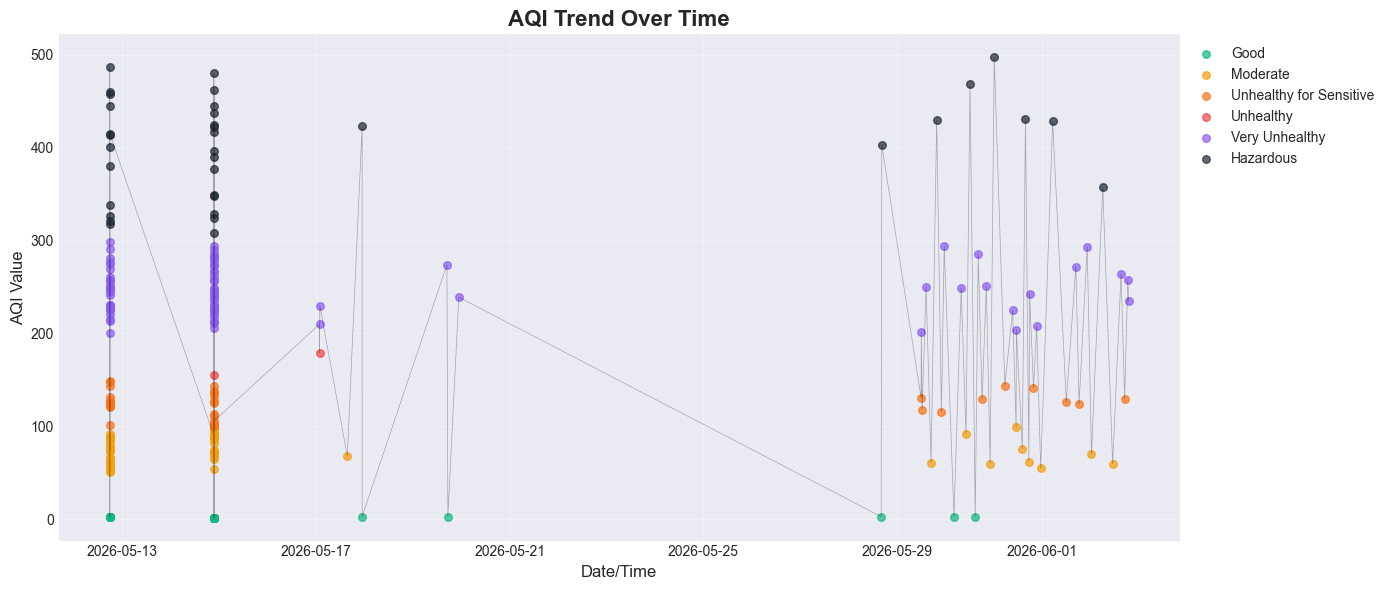

In [44]:
print("TIME SERIES ANALYSIS:")
print("-" *25)
# Convert datetime if not already
df['datetime'] = pd.to_datetime(df['datetime'])

# Sort by datetime
df_sorted = df.sort_values('datetime')

fig, ax = plt.subplots(figsize=(14, 6))

# Plot AQI over time with colors based on categories
for category, color in AQI_COLORS.items():
    mask = df_sorted['aqi_category'] == category
    ax.scatter(df_sorted.loc[mask, 'datetime'], 
               df_sorted.loc[mask, 'aqi'],
               c=color, label=category, alpha=0.7, s=30)

ax.plot(df_sorted['datetime'], df_sorted['aqi'], 'k-', alpha=0.3, linewidth=0.5)

ax.set_title('AQI Trend Over Time', fontsize=16, fontweight='bold')
ax.set_xlabel('Date/Time', fontsize=12)
ax.set_ylabel('AQI Value', fontsize=12)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

HOURLY PATTERN ANALYSIS:
------------------------------


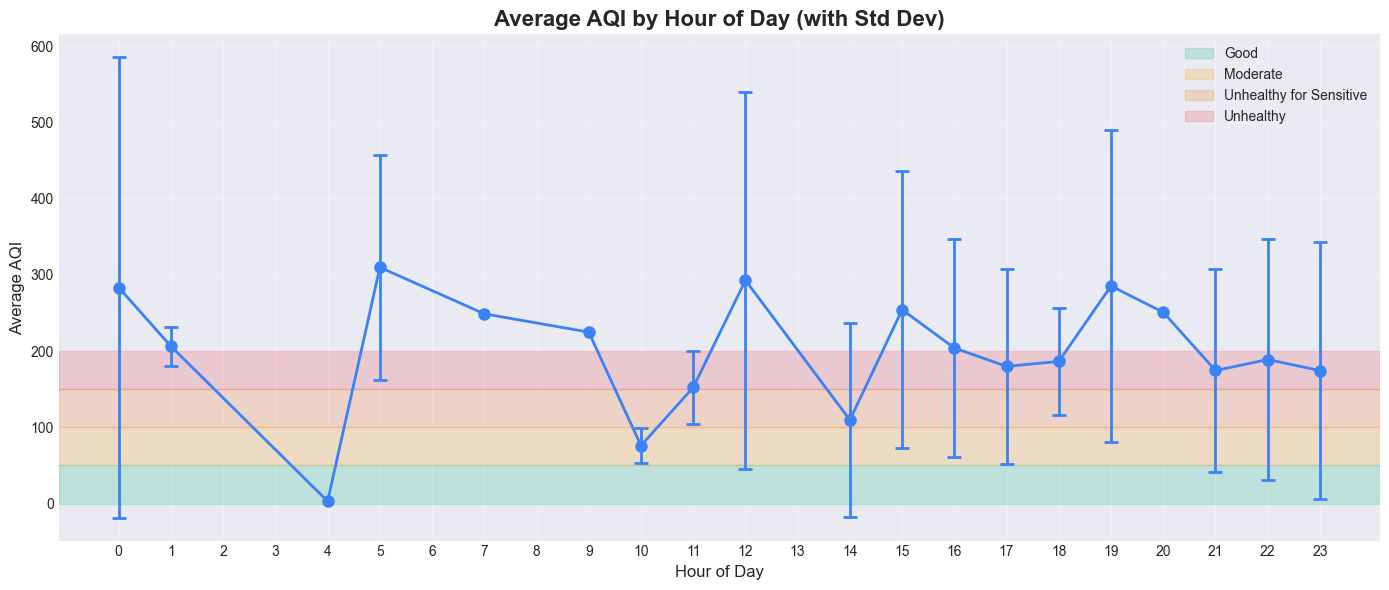


Peak Pollution Hours:
------------------------------
 hour  mean
    5 310.0
   12 293.0
   19 285.5


In [52]:
print("HOURLY PATTERN ANALYSIS:")
print("-"*30)

# Create hour column if not exists
if 'hour' not in df.columns:
    df['hour'] = df['datetime'].dt.hour

# Average AQI by hour
hourly_avg = df.groupby('hour')['aqi'].agg(['mean', 'std', 'count']).reset_index()

fig, ax = plt.subplots(figsize=(14, 6))

# Plot mean AQI by hour with error bars
ax.errorbar(hourly_avg['hour'], hourly_avg['mean'], 
            yerr=hourly_avg['std'], fmt='o-', 
            color='#3b82f6', capsize=5, capthick=2, 
            markersize=8, linewidth=2)

# Add AQI zone background
ax.axhspan(0, 50, alpha=0.2, color='#10b981', label='Good')
ax.axhspan(50, 100, alpha=0.2, color='#f59e0b', label='Moderate')
ax.axhspan(100, 150, alpha=0.2, color='#f97316', label='Unhealthy for Sensitive')
ax.axhspan(150, 200, alpha=0.2, color='#ef4444', label='Unhealthy')

ax.set_title('Average AQI by Hour of Day (with Std Dev)', fontsize=16, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Average AQI', fontsize=12)
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("\nPeak Pollution Hours:")
print("-"*30)
print(hourly_avg.nlargest(3, 'mean')[['hour', 'mean']].to_string(index=False))

MAJOR POLLUTANTS TREND:
------------------------------


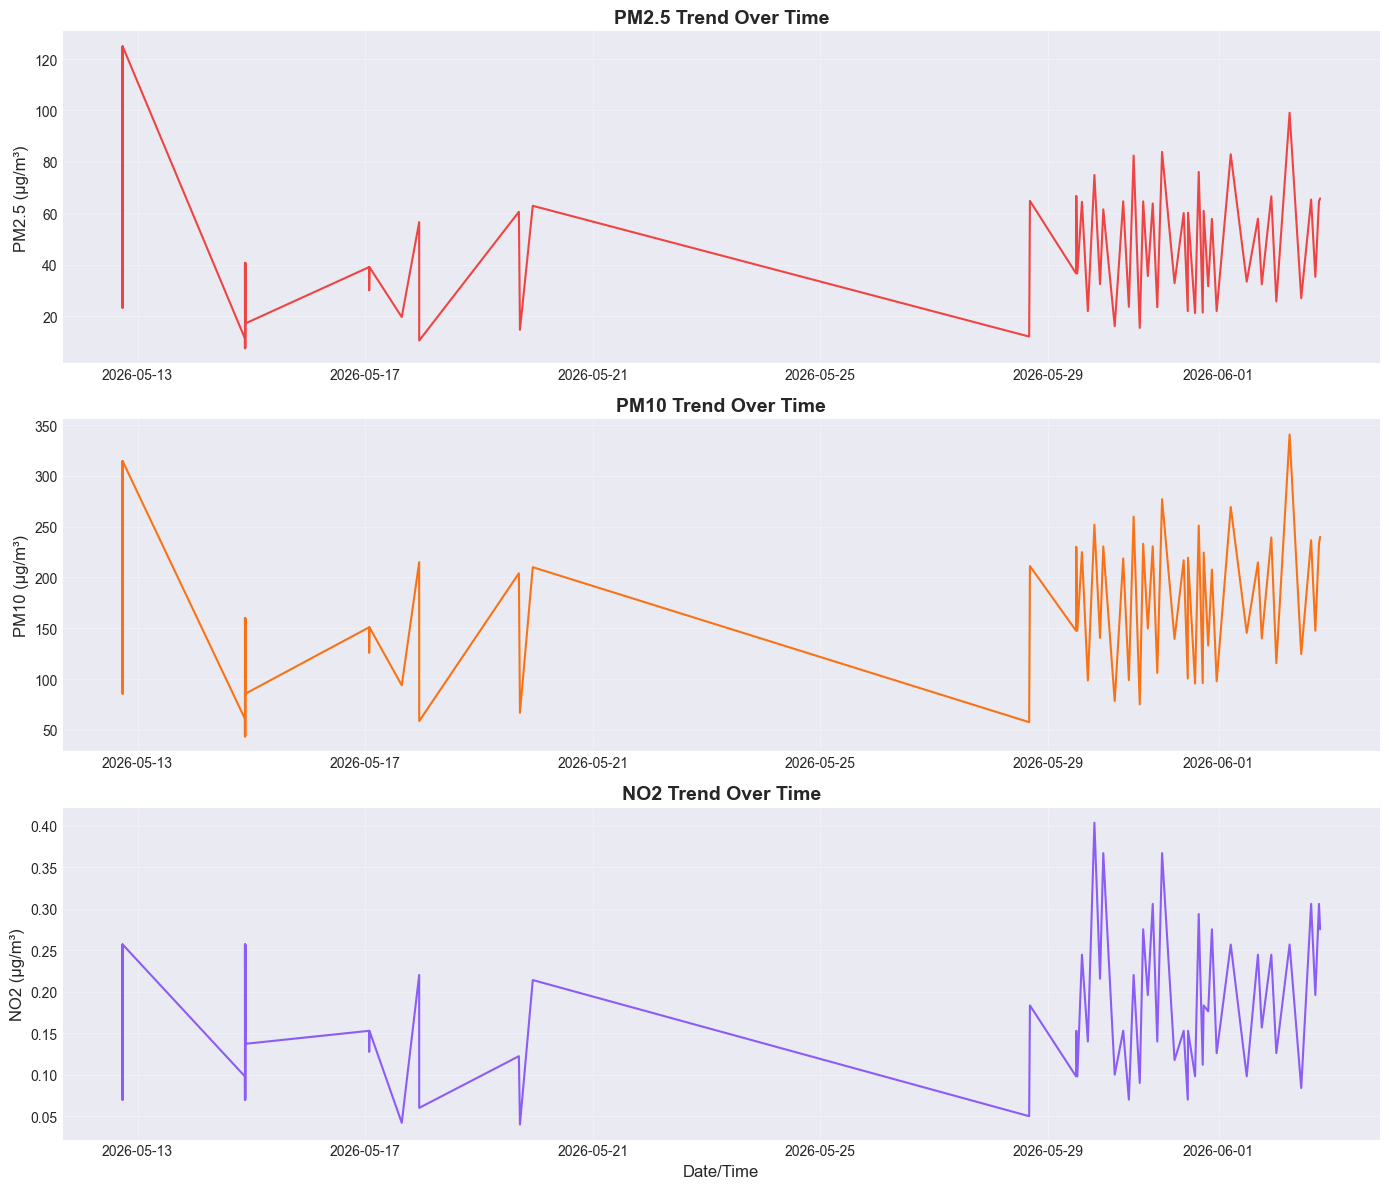

In [55]:
print("MAJOR POLLUTANTS TREND:")
print("-"*30)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# PM2.5 Trend
axes[0].plot(df_sorted['datetime'], df_sorted['pm2_5'], color='#ef4444', linewidth=1.5)
axes[0].set_title('PM2.5 Trend Over Time', fontsize=14, fontweight='bold')
axes[0].set_ylabel('PM2.5 (μg/m³)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# PM10 Trend
axes[1].plot(df_sorted['datetime'], df_sorted['pm10'], color='#f97316', linewidth=1.5)
axes[1].set_title('PM10 Trend Over Time', fontsize=14, fontweight='bold')
axes[1].set_ylabel('PM10 (μg/m³)', fontsize=12)
axes[1].grid(True, alpha=0.3)

# NO2 Trend
axes[2].plot(df_sorted['datetime'], df_sorted['no2'], color='#8b5cf6', linewidth=1.5)
axes[2].set_title('NO2 Trend Over Time', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Date/Time', fontsize=12)
axes[2].set_ylabel('NO2 (μg/m³)', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

FEATURE CORRELATION ANALYSIS:
------------------------------------------------------------


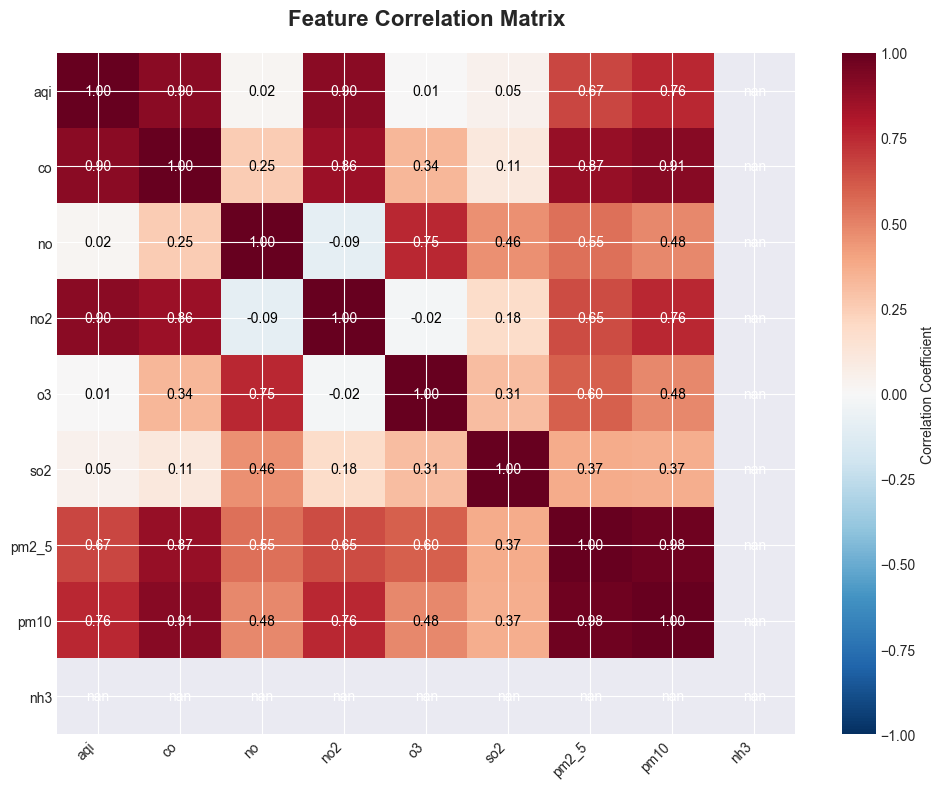


Top correlations with AQI:
------------------------------------------------------------
  no2       : 0.9027
  co        : 0.9023
  pm10      : 0.7578
  pm2_5     : 0.6713
  so2       : 0.0461
  no        : 0.0219
  o3        : 0.0073
  nh3       : nan


In [57]:
print("FEATURE CORRELATION ANALYSIS:")
print("-"*60)

# Select numerical columns for correlation
corr_cols = ['aqi', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

# Create heatmap
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

# Add colorbar
plt.colorbar(im, ax=ax, label='Correlation Coefficient')

# Set ticks
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)

# Add correlation values in cells
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                      ha="center", va="center", color="black" if abs(corr_matrix.iloc[i, j]) < 0.5 else "white",
                      fontsize=10)

ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\nTop correlations with AQI:")
print("-"*60)
aqi_corr = corr_matrix['aqi'].sort_values(ascending=False)
for feature, corr in aqi_corr.items():
    if feature != 'aqi':
        print(f"  {feature:10}: {corr:.4f}")

AQI DISTRIBUTION BY HOUR:
------------------------------------------------------------


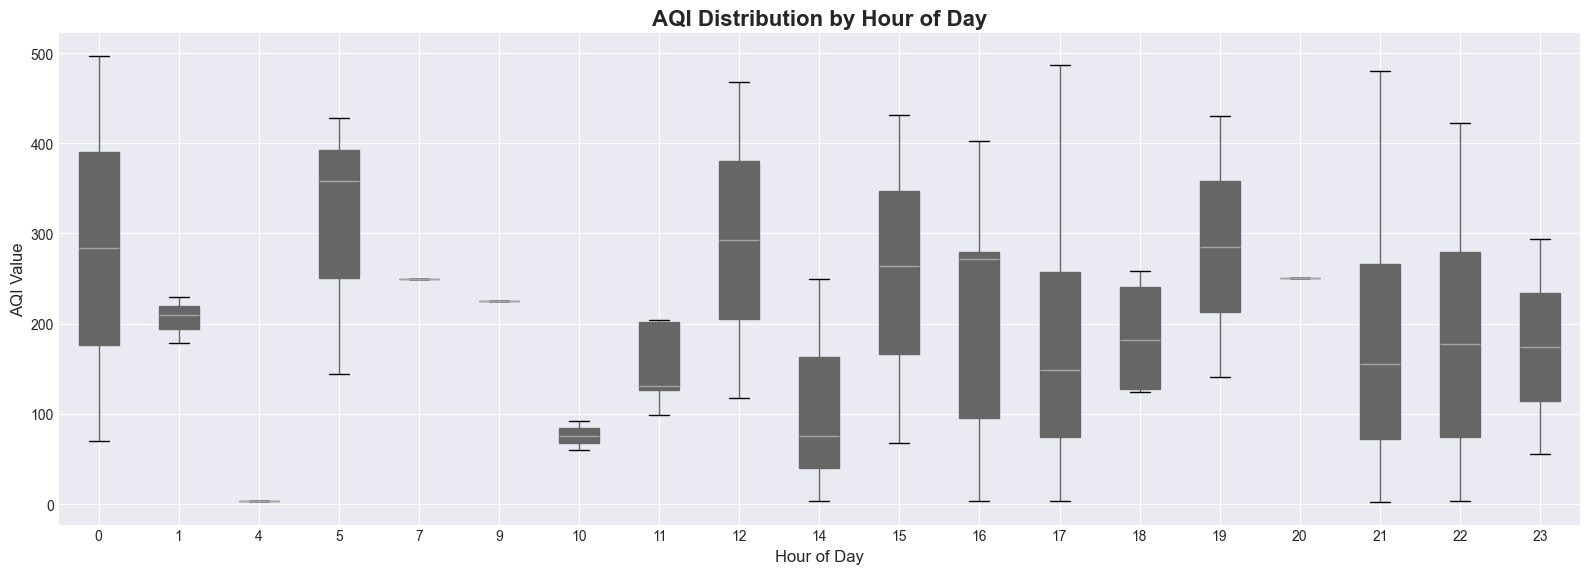

In [61]:
print("AQI DISTRIBUTION BY HOUR:")
print("-"*60)

fig, ax = plt.subplots(figsize=(16, 6))

# Create box plot
df.boxplot(column='aqi', by='hour', ax=ax, patch_artist=True)

# Color boxes based on average AQI
for i, box in enumerate(ax.artists):
    hour_avg = hourly_avg[hourly_avg['hour'] == i]['mean'].values
    if len(hour_avg) > 0:
        avg = hour_avg[0]
        if avg <= 50:
            box.set_facecolor('#10b981')
        elif avg <= 100:
            box.set_facecolor('#f59e0b')
        elif avg <= 150:
            box.set_facecolor('#f97316')
        elif avg <= 200:
            box.set_facecolor('#ef4444')
        else:
            box.set_facecolor('#8b5cf6')

ax.set_title('AQI Distribution by Hour of Day', fontsize=16, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('AQI Value', fontsize=12)

plt.suptitle('')  # Remove default title
plt.tight_layout()
plt.show()

WEEKDAY VS WEEKEND ANALYSIS:
------------------------------------------------------------

Weekday AQI Statistics:
  Mean: 181.50
  Median: 201.00
  Std: 130.16

Weekend AQI Statistics:
  Mean: 186.63
  Median: 179.00
  Std: 141.03


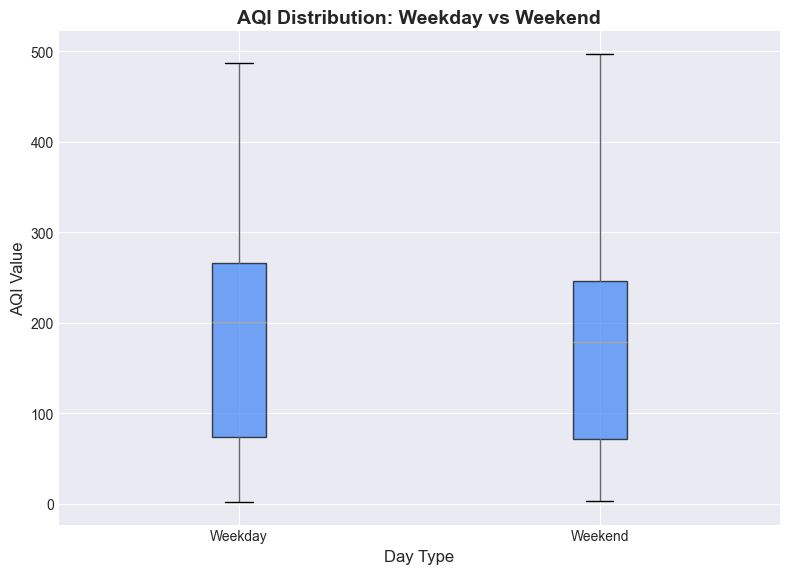

In [62]:
print("WEEKDAY VS WEEKEND ANALYSIS:")
print("-"*60)

# Add day of week if not exists
if 'day_of_week' not in df.columns:
    df['day_of_week'] = df['datetime'].dt.dayofweek

df['is_weekend'] = df['day_of_week'] >= 5
df['day_type'] = df['is_weekend'].map({True: 'Weekend', False: 'Weekday'})

# Calculate statistics
weekday_stats = df[df['day_type'] == 'Weekday']['aqi'].describe()
weekend_stats = df[df['day_type'] == 'Weekend']['aqi'].describe()

print("\nWeekday AQI Statistics:")
print(f"  Mean: {weekday_stats['mean']:.2f}")
print(f"  Median: {weekday_stats['50%']:.2f}")
print(f"  Std: {weekday_stats['std']:.2f}")

print("\nWeekend AQI Statistics:")
print(f"  Mean: {weekend_stats['mean']:.2f}")
print(f"  Median: {weekend_stats['50%']:.2f}")
print(f"  Std: {weekend_stats['std']:.2f}")

# Box plot comparison
fig, ax = plt.subplots(figsize=(8, 6))

df.boxplot(column='aqi', by='day_type', ax=ax, patch_artist=True,
           boxprops=dict(facecolor='#3b82f6', alpha=0.7))

ax.set_title('AQI Distribution: Weekday vs Weekend', fontsize=14, fontweight='bold')
ax.set_xlabel('Day Type', fontsize=12)
ax.set_ylabel('AQI Value', fontsize=12)
plt.suptitle('')

plt.tight_layout()
plt.show()

INTERACTIVE DASHBOARD (PLOTLY):
------------------------------------------------------------


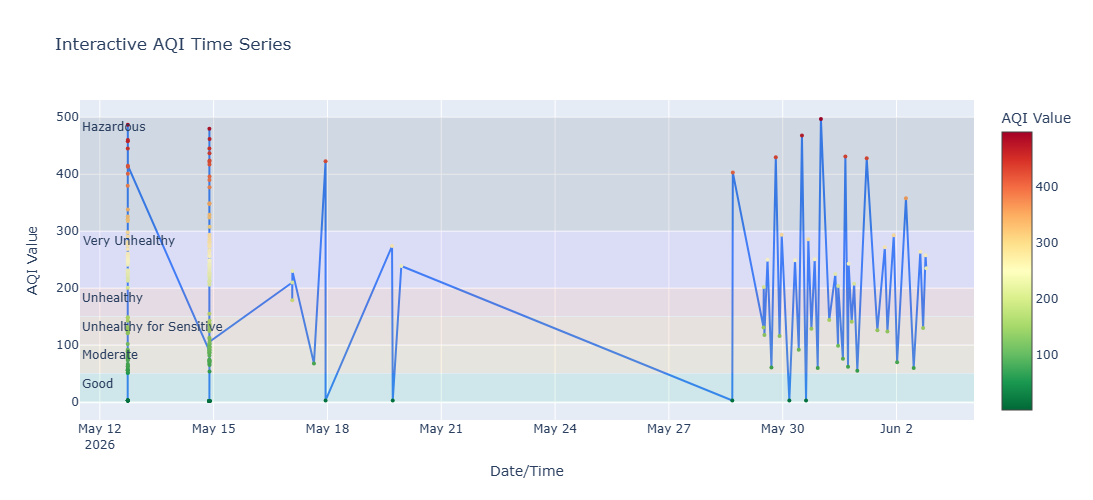

In [63]:
print("INTERACTIVE DASHBOARD (PLOTLY):")
print("-"*60)

# Create interactive time series plot
fig = go.Figure()

# Add AQI line
fig.add_trace(go.Scatter(
    x=df_sorted['datetime'],
    y=df_sorted['aqi'],
    mode='lines+markers',
    name='AQI',
    line=dict(color='#3b82f6', width=2),
    marker=dict(size=4, color=df_sorted['aqi'], 
                colorscale='RdYlGn_r',
                showscale=True,
                colorbar=dict(title="AQI Value")),
    hovertemplate='<b>Time:</b> %{x}<br><b>AQI:</b> %{y}<extra></extra>'
))

# Add zone rectangles
for start, end, label, color in AQI_RANGES:
    fig.add_hrect(y0=start, y1=end, fillcolor=color, opacity=0.1, line_width=0,
                  annotation_text=label, annotation_position="top left")

fig.update_layout(
    title='Interactive AQI Time Series',
    xaxis_title='Date/Time',
    yaxis_title='AQI Value',
    height=500,
    hovermode='x unified'
)

fig.show()

In [64]:
print("EDA SUMMARY REPORT:")
print("-"*60)

print("\n DATASET OVERVIEW:")
print(f"   Total Records: {len(df)}")
print(f"   Date Range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"   Features: {df.shape[1]}")

print("\n AQI STATISTICS:")
print(f"   Mean AQI: {df['aqi'].mean():.2f}")
print(f"   Median AQI: {df['aqi'].median():.2f}")
print(f"   Std Dev: {df['aqi'].std():.2f}")
print(f"   Min AQI: {df['aqi'].min():.2f}")
print(f"   Max AQI: {df['aqi'].max():.2f}")

print("\n TOP CORRELATIONS WITH AQI:")
aqi_corr = corr_matrix['aqi'].sort_values(ascending=False)
for feature, corr in aqi_corr.items():
    if feature != 'aqi':
        print(f"   {feature.upper()}: {corr:.4f}")

print("\n PEAK POLLUTION HOURS:")
peak_hours = hourly_avg.nlargest(3, 'mean')[['hour', 'mean']]
for _, row in peak_hours.iterrows():
    print(f"   {int(row['hour']):02d}:00 - AQI: {row['mean']:.1f}")

print("-"*60)
print("\n EDA COMPLETED SUCCESSFULLY!")

EDA SUMMARY REPORT:
------------------------------------------------------------

 DATASET OVERVIEW:
   Total Records: 230
   Date Range: 2026-05-12 17:37:34.401042 to 2026-06-02 18:50:14.335006
   Features: 38

 AQI STATISTICS:
   Mean AQI: 182.10
   Median AQI: 190.00
   Std Dev: 131.17
   Min AQI: 2.00
   Max AQI: 497.00

 TOP CORRELATIONS WITH AQI:
   NO2: 0.9027
   CO: 0.9023
   PM10: 0.7578
   PM2_5: 0.6713
   SO2: 0.0461
   NO: 0.0219
   O3: 0.0073
   NH3: nan

 PEAK POLLUTION HOURS:
   05:00 - AQI: 310.0
   12:00 - AQI: 293.0
   19:00 - AQI: 285.5
------------------------------------------------------------

 EDA COMPLETED SUCCESSFULLY!
